<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#The-Wiener-filter" data-toc-modified-id="The-Wiener-filter-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>The Wiener filter</a></span><ul class="toc-item"><li><span><a href="#DC-motor-plant-configuration" data-toc-modified-id="DC-motor-plant-configuration-1.1"><span class="toc-item-num">1.1&nbsp;&nbsp;</span>DC motor plant configuration</a></span></li><li><span><a href="#Input-output-data-generation" data-toc-modified-id="Input-output-data-generation-1.2"><span class="toc-item-num">1.2&nbsp;&nbsp;</span>Input-output data generation</a></span></li><li><span><a href="#Numerical-estimation-of-correlation-matrix-R-and-cross-correlation-vector-p" data-toc-modified-id="Numerical-estimation-of-correlation-matrix-R-and-cross-correlation-vector-p-1.3"><span class="toc-item-num">1.3&nbsp;&nbsp;</span>Numerical estimation of correlation matrix $R$ and cross-correlation vector $p$</a></span></li></ul></li><li><span><a href="#Least-Mean-Square-(LMS)-algorithm" data-toc-modified-id="Least-Mean-Square-(LMS)-algorithm-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Least-Mean-Square (LMS) algorithm</a></span><ul class="toc-item"><li><span><a href="#Example:-DC-motor-system-identification" data-toc-modified-id="Example:-DC-motor-system-identification-2.1"><span class="toc-item-num">2.1&nbsp;&nbsp;</span>Example: DC motor system identification</a></span></li><li><span><a href="#Convergence-behavior-for-different-values-of-step-size" data-toc-modified-id="Convergence-behavior-for-different-values-of-step-size-2.2"><span class="toc-item-num">2.2&nbsp;&nbsp;</span>Convergence behavior for different values of step-size</a></span></li></ul></li></ul></div>

import os
import time
from pathlib import Path

# Configure a local Matplotlib cache when running outside the notebooks folder.
os.environ.setdefault('MPLCONFIGDIR', str(Path.cwd() / '.matplotlib'))
Path(os.environ['MPLCONFIGDIR']).mkdir(exist_ok=True)

import sympy as sp
from sympy import latex
import numpy as np
try:
    from IPython.display import Math, Latex, display
except Exception:
    Math = Latex = lambda x: x
    display = print
import matplotlib.pyplot as plt
from scipy import signal
from scipy.signal import freqz

In [2]:
try:
    from IPython.core.display import HTML
    from IPython.display import Image
except Exception:
    HTML = Image = lambda *args, **kwargs: None

try:
    import scienceplots
except Exception:
    scienceplots = None

try:
    from utils import set_preferences, symdisp, round_expr
except Exception:
    def set_preferences():
        plt.rcParams['figure.figsize'] = [5, 2.5]
        plt.rcParams['figure.dpi'] = 150
        plt.rcParams['grid.linestyle'] = 'dashed'
        plt.rcParams['grid.alpha'] = 0.25
        plt.rcParams['legend.frameon'] = False

    def symdisp(expr, value, numDig=3):
        print(expr, np.array(value, dtype=object))

    def round_expr(expr, numDig=3):
        return expr

if scienceplots is not None:
    plt.style.use(['science','ieee'])

set_preferences()
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'Times', 'DejaVu Serif']

plt.rcParams['figure.figsize'] = [5, 2.5]
plt.rcParams['figure.dpi'] = 150

saveFigures = True
figurePath = './figures/'

In [3]:

def power_to_db(power):
    """Convert positive power values to dB and mask undefined zero-power points."""
    power = np.asarray(power, dtype=np.float64)
    positive = power > 0
    power_dB = np.full(power.shape, np.nan, dtype=np.float64)
    power_dB[positive] = 10*np.log10(power[positive])
    return power_dB


# Identificação de motor DC com filtros adaptativos LMS e NLMS

Este notebook replica a estrutura dos notebooks **The Wiener filter and the LMS algorithm** e **Variants of LMS algorithm**, substituindo a planta FIR didática por uma planta simulada de motor DC. O objetivo é manter o mesmo encadeamento computacional: geração de dados, estimação de $R$ e $p$, filtro de Wiener como referência e comparação entre LMS e NLMS.

A proposta é reproduzir computacionalmente a lógica do estudo de caso do artigo: representar a dinâmica do motor por um filtro FIR, estimar seus coeficientes a partir de dados de entrada e saída, e comparar erro de identificação e tempo de processamento. Como não há bancada física neste projeto, os dados são gerados por uma planta discreta simulada.

**TODO:** Ajustar Markdowns e seções.

## Estratégia de replicação computacional

A planta real do artigo será substituída por um modelo simulado de motor DC. A entrada aplicada ao motor será um sinal pseudoaleatório binário, usado para excitar a dinâmica da planta. A saída simulada do motor será usada como sinal desejado para a identificação adaptativa.

A estrutura de identificação é

$$
d[k] = G(q) x[k] + v[k]
$$

em que $x[k]$ é a entrada aplicada ao motor, $d[k]$ é a saída medida/simulada, $G(q)$ representa a planta discreta e $v[k]$ representa ruído de medição opcional.

O filtro FIR adaptativo estima a saída por

$$
\hat{d}[k] = \boldsymbol{h}^T[k]\boldsymbol{x}[k]
$$

com

$$
\boldsymbol{x}[k] = [x[k], x[k-1], \ldots, x[k-M+1]]^T.
$$

No artigo, o sinal de entrada e a saída do motor são adquiridos em tempo real por uma placa STM32 Nucleo. Aqui, essa etapa é substituída por simulação numérica, preservando o mesmo problema de identificação: ajustar um modelo FIR cuja saída acompanhe a saída do motor.

**TODO:** comparar os parâmetros de simulação com os valores reportados no artigo e ajustar a excitação SPAB/PRBS conforme necessário.

## The Wiener filter

### DC motor plant configuration

A planta do motor DC é representada em espaço de estados contínuo. O vetor de estados é

$$
\boldsymbol{x}(t) =
\begin{bmatrix}
 i_a(t) & \omega_m(t) & \theta_m(t)
\end{bmatrix}^T,
$$

em que $i_a(t)$ é a corrente de armadura, $\omega_m(t)$ é a velocidade angular e $\theta_m(t)$ é a posição angular. A saída usada na identificação é a velocidade angular em rpm.

O filtro de Wiener é usado como referência em lote. Ele não é um algoritmo adaptativo online no sentido do LMS/NLMS, mas fornece uma solução FIR ótima em termos de erro quadrático médio para os dados disponíveis.

### Parâmetros da simulação

Nesta etapa são definidos o período de amostragem, o número de amostras, a variância do ruído e os parâmetros nominais do motor DC.

Como referência principal, adota-se o modelo em espaço de estados contínuo apresentado na Seção II.A do artigo. O vetor de estados é definido por

$$
\mathbf{x}(t) =
\begin{bmatrix}
i_a(t) \\
\omega_m(t) \\
\theta_m(t)
\end{bmatrix},
$$

em que $i_a(t)$ é a corrente de armadura, $\omega_m(t)$ é a velocidade angular e $\theta_m(t)$ é a posição angular.

O modelo contínuo é dado por

$$
\dot{\mathbf{x}}(t) =
\mathbf{A}\mathbf{x}(t) + \mathbf{B}u_a(t),
$$

com

$$
\mathbf{A} =
\begin{bmatrix}
-\frac{R_a}{L_a} & -\frac{K_e}{L_a} & 0 \\
\frac{K_t}{J_m} & -\frac{D_m}{J_m} & 0 \\
0 & 1 & 0
\end{bmatrix},
\quad
\mathbf{B} =
\begin{bmatrix}
\frac{1}{L_a} \\
0 \\
0
\end{bmatrix}.
$$

Neste notebook, os parâmetros físicos são definidos nominalmente apenas para simular a planta. A identificação será realizada por filtros FIR adaptativos, que aproximam o comportamento entrada-saída do motor, e não por estimação direta dos parâmetros físicos.

O período de amostragem é mantido em $T_s=1$ ms, coerente com o valor informado no artigo para a aquisição dos sinais.

**TODO:** substituir estes parâmetros por valores consistentes com o artigo ou justificar a escolha de um conjunto nominal.

* o que justifica a escolha desses parâmetros?
* o que justifica a escolha desse erro?
* existem referências?
* referência para a correção feita?
    * https://ctms.engin.umich.edu/CTMS/index.php?example=MotorSpeed&section=SystemModeling
    * https://ctms.engin.umich.edu/CTMS/?example=MotorPosition&section=SystemModeling
* planta não é fir, mas será aproximada por FIR
* trocar x[k] por u[k] na entrada discreta para evitar conflito com o vetor de estados;
* explicitar depois a matriz de saída C, já que você disse que a saída usada é velocidade em rpm.

### Parâmetros da simulação

Nesta etapa são definidos os parâmetros usados para gerar os dados simulados de entrada e saída do motor DC. Esses parâmetros podem ser divididos em dois grupos:

1. parâmetros de amostragem e ruído;
2. parâmetros físicos nominais da planta do motor DC.

O período de amostragem adotado é

$$
T_s = 1\ \text{ms},
$$

coerente com o valor informado no artigo para a aquisição dos sinais. Assim, a frequência de amostragem é

$$
f_s = \frac{1}{T_s} = 1000\ \text{Hz}.
$$

O número total de amostras é definido por `nsamples`. Como neste notebook são usadas `100000` amostras, o tempo total de simulação é

$$
T_{\text{sim}} = N T_s = 100000 \cdot 0{,}001 = 100\ \text{s}.
$$

A variância do ruído de medição é definida por

$$
\sigma^2 = 0{,}5\ \text{rpm}^2.
$$

Caso o ruído seja gerado como uma variável aleatória gaussiana de média nula, seu desvio padrão será

$$
\sigma = \sqrt{0{,}5} \approx 0{,}707\ \text{rpm}.
$$

Esse ruído representa imperfeições de medição, quantização, perturbações externas ou componentes não modeladas da planta.

---

O motor DC é representado inicialmente por um modelo em espaço de estados contínuo. O vetor de estados é definido como

$$
\mathbf{x}(t) =
\begin{bmatrix}
i_a(t) \
\omega_m(t) \
\theta_m(t)
\end{bmatrix},
$$

em que $i_a(t)$ é a corrente de armadura, $\omega_m(t)$ é a velocidade angular e $\theta_m(t)$ é a posição angular.

O modelo contínuo é dado por

$$
\dot{\mathbf{x}}(t) =
\mathbf{A}\mathbf{x}(t) + \mathbf{B}u_a(t),
$$

com

$$
\mathbf{A} =
\begin{bmatrix}
-\frac{R_a}{L_a} & -\frac{K_e}{L_a} & 0 \
\frac{K_t}{J_m} & -\frac{D_m}{J_m} & 0 \
0 & 1 & 0
\end{bmatrix},
\quad
\mathbf{B} =
\begin{bmatrix}
\frac{1}{L_a} \
0 \
0
\end{bmatrix}.
$$

Os parâmetros físicos nominais usados na simulação são:

| Parâmetro | Significado                           | Unidade                                  |
| --------- | ------------------------------------- | ---------------------------------------- |
| $J_m$     | momento de inércia equivalente        | $\text{kg}\cdot\text{m}^2$               |
| $D_m$     | coeficiente de atrito viscoso         | $\text{N}\cdot\text{m}\cdot\text{s/rad}$ |
| $K_t$     | constante de torque                   | $\text{N}\cdot\text{m/A}$                |
| $K_e$     | constante de força contraeletromotriz | $\text{V}\cdot\text{s/rad}$              |
| $R_a$     | resistência de armadura               | $\Omega$                                 |
| $L_a$     | indutância de armadura                | $\text{H}$                               |

A constante $J_m$ determina a resistência mecânica do rotor a variações de velocidade. Quanto maior seu valor, mais lenta tende a ser a resposta mecânica do motor.

O coeficiente $D_m$ representa o atrito viscoso, isto é, um torque contrário proporcional à velocidade angular:

$$
T_{\text{atrito}}(t) = D_m\omega_m(t).
$$

A constante $K_t$ converte corrente de armadura em torque eletromagnético:

$$
T_m(t) = K_t i_a(t).
$$

A constante $K_e$ representa a força contraeletromotriz gerada pela rotação do motor:

$$
e_b(t) = K_e\omega_m(t).
$$

Essa tensão se opõe à tensão aplicada e, por isso, aparece com sinal negativo na equação elétrica do motor.

A resistência $R_a$ limita a corrente no circuito de armadura, enquanto a indutância $L_a$ determina a dinâmica elétrica da corrente. A constante de tempo elétrica aproximada é

$$
\tau_e = \frac{L_a}{R_a}.
$$

Com os valores adotados neste notebook,

$$
\tau_e = \frac{0{,}012}{2} = 0{,}006\ \text{s} = 6\ \text{ms}.
$$

Portanto, a corrente de armadura não varia instantaneamente; ela possui uma dinâmica própria.

---

É importante destacar que os parâmetros físicos definidos nesta etapa são usados apenas para gerar uma planta simulada. A identificação realizada neste notebook não estima diretamente $R_a$, $L_a$, $K_e$, $K_t$, $J_m$ e $D_m$. Em vez disso, os filtros adaptativos LMS e NLMS estimam um modelo FIR equivalente que aproxima a relação entrada-saída do motor.

Assim, o fluxo da simulação é

$$
R_a,L_a,K_e,K_t,J_m,D_m
\rightarrow
\mathbf{A},\mathbf{B},\mathbf{C},\mathbf{D}
\rightarrow
\text{planta discreta simulada}
\rightarrow
u[k],d[k]
\rightarrow
\text{identificação FIR adaptativa}.
$$


In [4]:
# Sampling parameters
fs = 1000
Ts = 1/fs
nsamples = 100000
sigma2 = 0.1 # 0.5 # noise variance in (rpm)^2

# Nominal physical parameters of the DC motor
Jm = 8.1e-5      # equivalent inertia [kg.m^2]
Dm = 4.35e-3     # viscous friction [N.m.s]
Kt = 0.02        # torque constant [N.m/A]
Ke = 0.02        # back-EMF constant [V.s/rad]
Ra = 2.0         # armature resistance [ohm]
La = 1.2e-2        # armature inductance [H]

print(f'Ts = {Ts:.4e} s, nsamples = {nsamples}')

Ts = 1.0000e-03 s, nsamples = 100000


Os parâmetros físicos adotados nesta simulação foram escolhidos de modo a gerar uma planta discreta com dinâmica compatível com o período de amostragem e com a ordem FIR utilizada no artigo. Em particular, o artigo utiliza (T_s = 1) ms e adota (M=55) coeficientes para o filtro FIR identificado.

Para verificar a compatibilidade entre a planta simulada e essa escolha de ordem, foi estimada a resposta ao impulso discreta do motor. Em seguida, calculou-se o número de coeficientes necessário para acumular 99% da energia da resposta ao impulso:

$$
E_N =
\frac{\sum_{k=0}^{N-1} g^2[k]}
{\sum_{k=0}^{\infty} g^2[k]}.
$$

Com os parâmetros nominais adotados, obteve-se:

$$
N_{99%}=52.
$$

Como o filtro FIR usado no notebook possui (M=55) coeficientes, ele é capaz de representar praticamente toda a dinâmica dominante da planta simulada. Considerando (T_s=1) ms, isso significa que 99% da energia da resposta ao impulso está concentrada aproximadamente nos primeiros

$$
52T_s = 52\ \text{ms}.
$$

Portanto, os parâmetros físicos não foram escolhidos com o objetivo de reproduzir exatamente o motor real do artigo, cujos parâmetros não são informados, mas sim para construir uma planta simulada cuja duração efetiva da resposta ao impulso seja coerente com a ordem FIR usada no estudo de caso.



### Planta simulada do motor DC

A planta contínua do motor DC é representada em espaço de estados, seguindo a estrutura apresentada na Seção II.A do artigo. O modelo possui três estados: corrente de armadura, velocidade angular e posição angular.

A saída usada neste notebook será a velocidade angular simulada:

$$
d[k] = \omega_m[k] + v[k],
$$

em que $v[k]$ representa ruído branco de medição.

O modelo contínuo será discretizado com retentor de ordem zero, usando o período de amostragem $T_s$.

A simulação substitui a etapa experimental de aquisição. Portanto, a identificação continua sendo feita a partir de pares entrada-saída, mas a origem dos dados é uma planta conhecida, o que facilita verificar o comportamento dos algoritmos.

**TODO:** Verificar as matrizes

In [5]:
# Continuous-time state-space model
A = np.array([
    [-Ra/La,  -Ke/La,   0.0],
    [ Kt/Jm,  -Dm/Jm,   0.0],
    [ 0.0,     1.0,     0.0]
])

B = np.array([
    [1.0/La],
    [0.0],
    [0.0]
])

C = np.array([
    [0.0, 1.0, 0.0]
])

D = np.array([
    [0.0]
])

# Discretize the plant using zero-order hold
Ad, Bd, Cd, Dd, dt = signal.cont2discrete((A, B, C, D), Ts, method='zoh')

symdisp('\\boldsymbol{A} = ', sp.Matrix(A), numDig=4)
symdisp('\\boldsymbol{B} = ', sp.Matrix(B), numDig=4)
symdisp('\\boldsymbol{C} = ', sp.Matrix(C), numDig=4)
symdisp('\\boldsymbol{A}_d = ', sp.Matrix(Ad), numDig=4)
symdisp('\\boldsymbol{B}_d = ', sp.Matrix(Bd), numDig=4)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

### Input-output data generation

O sinal de entrada é uma sequência binária pseudoaleatória aplicada como tensão de armadura. A saída desejada $d[k]$ é obtida pela simulação da planta discreta e pela adição opcional de ruído de medição.

No artigo, o sinal SPAB é usado para excitar diferentes modos dinâmicos do motor sem levar o sistema à saturação. O mesmo princípio é adotado aqui: a entrada alterna entre dois níveis de tensão próximos ao ponto de operação, produzindo variações suficientes para a estimação do modelo FIR.

Como o artigo não fornece uma variância numérica para o ruído de medição, adota-se neste notebook uma perturbação gaussiana de média nula apenas para representar imperfeições de medição. A variância escolhida é $σ^2=0,1 rpm^2$, correspondente a um desvio padrão de aproximadamente $0,316 rpm$. Esse valor é pequeno em relação à velocidade nominal do motor e permite avaliar os algoritmos em um cenário de baixo ruído, sem mascarar a dinâmica causada pela entrada pseudoaleatória.

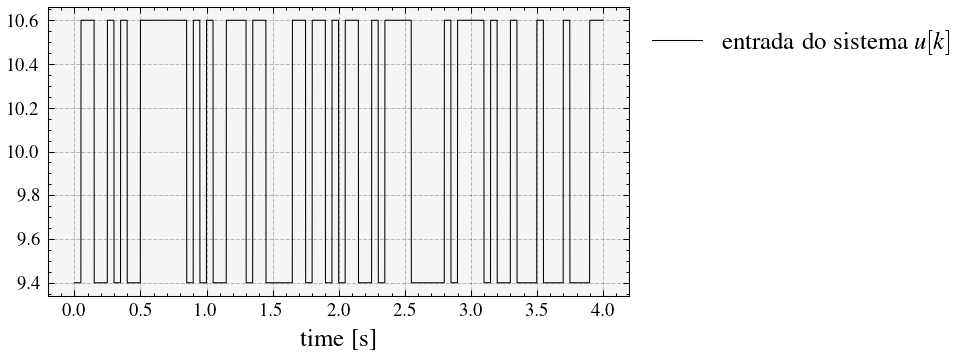

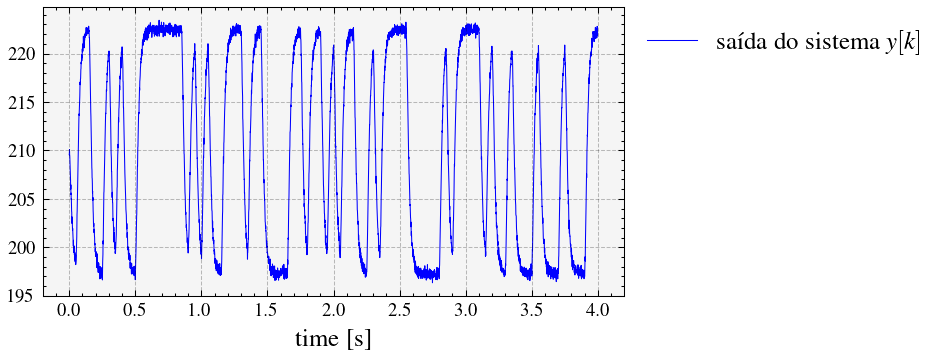

In [19]:
def generate_prbs(nsamples, amplitude=1.0, samples_per_bit=50, seed=42):
    """Generate a pseudo-random binary sequence with sample-and-hold behavior."""
    rng = np.random.default_rng(seed)
    n_bits = int(np.ceil(nsamples / samples_per_bit))
    bits = rng.choice([-amplitude, amplitude], size=n_bits)
    return np.repeat(bits, samples_per_bit)[:nsamples]


# Define input signal to the system
x_prbs = generate_prbs(nsamples, amplitude=1.0, samples_per_bit=50, seed=42)
u0 = 10.0
delta_u = 0.6
u = u0 + delta_u*x_prbs

timeIdx = np.arange(nsamples)*Ts

# Initial condition close to the nominal operating point
omega0 = u0/(Ke + Ra*Dm/Kt)
ia0 = (Dm/Kt)*omega0
theta0 = 0.0
x0 = np.array([ia0, omega0, theta0])

# Simulate the DC motor plant
_, y_rad_s, Xstates = signal.dlsim((Ad, Bd, Cd, Dd, dt), u, x0=x0)
y = np.squeeze(y_rad_s)*60/(2*np.pi)

# Generate noise and add noise to the system output
rng = np.random.default_rng(123)
n = rng.normal(0, np.sqrt(sigma2), nsamples)
y += n

plt.figure()
plt.plot(timeIdx[0:4000], u[0:4000], '-k', label='entrada do sistema $u[k]$')
plt.legend(bbox_to_anchor=(1, 1));
plt.xlabel('time [s]')
plt.grid()

plt.figure()
plt.plot(timeIdx[0:4000], y[0:4000], '-b', markersize=2, label='saída do sistema $y[k]$')
plt.legend(bbox_to_anchor=(1, 1));
plt.xlabel('time [s]')
plt.grid()

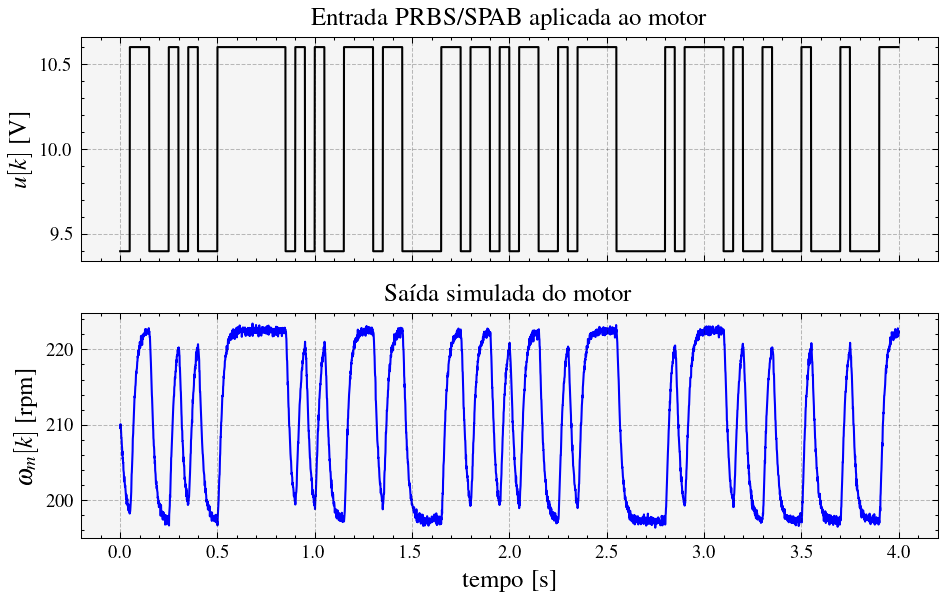

In [22]:
fig, ax = plt.subplots(2, 1, figsize=(6.5, 4.2), sharex=True)

# Entrada
ax[0].plot(timeIdx[0:4000], u[0:4000], '-k', linewidth=1)
ax[0].set_ylabel('$u[k]$ [V]')
ax[0].set_title('Entrada PRBS/SPAB aplicada ao motor')
ax[0].grid(True)

# Saída
ax[1].plot(timeIdx[0:4000], y[0:4000], '-b', linewidth=1)
ax[1].set_ylabel('$\\omega_m[k]$ [rpm]')
ax[1].set_xlabel('tempo [s]')
ax[1].set_title('Saída simulada do motor')
ax[1].grid(True)

fig.tight_layout()
plt.savefig('entrada_saida_motor.png', dpi=300, bbox_inches='tight')
plt.show()

Como o artigo não informa uma variância numérica para o ruído de medição, o valor adotado neste notebook é tratado como uma hipótese de simulação. A variância escolhida foi

$$
\sigma^2 = 0{,}1\ \text{rpm}^2,
$$

o que corresponde a um desvio padrão

$$
\sigma = \sqrt{0{,}1} \approx 0{,}316\ \text{rpm}.
$$

Esse valor é considerado baixo em relação à escala da saída simulada. Com os parâmetros nominais adotados, a velocidade de operação em torno de (u_0=10) V é da ordem de (210) rpm, de modo que o desvio padrão do ruído representa aproximadamente (0{,}15%) da velocidade nominal.

Além disso, a perturbação de entrada (\Delta u=0{,}6) V produz uma variação de velocidade da ordem de dezenas de rpm. Assim, o ruído adotado não domina a variação dinâmica provocada pela entrada pseudoaleatória, permitindo avaliar os algoritmos adaptativos em um cenário de baixo ruído de medição.

Para tornar essa escolha quantitativa, a razão sinal-ruído pode ser calculada a partir da saída simulada sem ruído:

$$
SNR_{\text{dB}} =
10\log_{10}
\left(
\frac{\operatorname{var}(d_{\text{clean}}[k])}{\sigma^2}
\right).
$$

Dessa forma, o valor de ruído não é assumido como uma característica real do sensor utilizado no artigo, mas como um parâmetro controlado de simulação para avaliar o comportamento dos algoritmos de identificação.


In [20]:
d_clean = np.squeeze(y_rad_s)*60/(2*np.pi)
d0 = omega0*60/(2*np.pi)

d_clean_id = d_clean - d0

SNR_dB = 10*np.log10(np.var(d_clean_id)/sigma2)

print(f'SNR = {SNR_dB:.2f} dB')

SNR = 30.11 dB


Estimated impulse-response length for 99% energy: 52
Number of FIR coefficients used in this notebook: 55


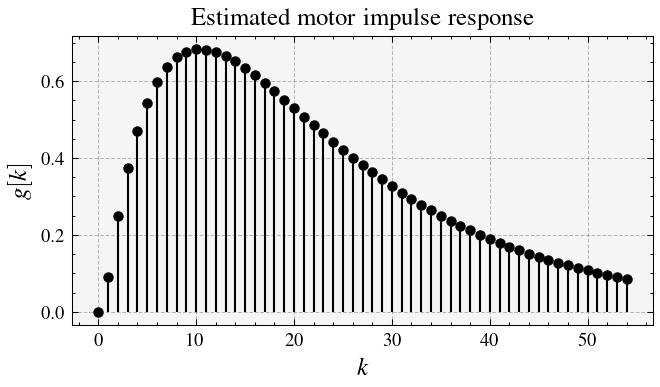

In [21]:
# Estimate an impulse response of the simulated motor to guide the filter length
Nimp = 500
impulse = np.zeros(Nimp)
impulse[0] = 1.0
_, g_rad_s, _ = signal.dlsim((Ad, Bd, Cd, Dd, dt), impulse)
g_full = np.squeeze(g_rad_s)*60/(2*np.pi)

energy = np.cumsum(g_full**2)/np.sum(g_full**2)
Ncoefs_est = np.searchsorted(energy, 0.99) + 1

# Use the article-oriented FIR length as the working number of taps
Ncoefs = 55
Ntaps = Ncoefs
g = g_full[:Ntaps]

print(f'Estimated impulse-response length for 99% energy: {Ncoefs_est}')
print(f'Number of FIR coefficients used in this notebook: {Ntaps}')

plt.figure()
plt.vlines(np.arange(len(g)), 0, g, linewidth=1)
plt.plot(g, 'ok', markersize=4)
plt.xlabel('$k$')
plt.ylabel('$g[k]$')
plt.title('Estimated motor impulse response')
plt.grid();

### Numerical estimation of correlation matrix $R$ and cross-correlation vector $p$

Como no notebook de referência, as estatísticas de segunda ordem são estimadas numericamente a partir dos sinais de entrada e saída. Antes da estimação, remove-se o valor médio calculado no conjunto de treino.

A solução de Wiener é obtida por

$$
\boldsymbol{h}_{opt}=\boldsymbol{R}_{xx}^{-1}\boldsymbol{p}_{yx},
$$

em que $\boldsymbol{R}_{xx}$ é a matriz de autocorrelação da entrada e $\boldsymbol{p}_{yx}$ é o vetor de correlação cruzada entre a entrada e a saída desejada.

In [9]:
def estimate_correlation_matrix(x, N):
    # sourcery skip: inline-immediately-returned-variable
    """
    Estimate the unbiased correlation matrix R of order N from a sequence of random values x.

    Parameters
    ----------
    x : array-like
        The sequence of random values (x0, x1, ..., xM-1) of length M.
    N : int
        The order of the correlation matrix. Must be less than or equal to M.

    Returns
    -------
    R : np.ndarray
        The estimated unbiased correlation matrix of shape (N, N).
    """
    M = len(x)
    if N > M:
        raise ValueError(
            "Order N should be smaller than or equal to the length of the sequence M."
        )

    # Create a matrix where each row is a shifted version of the original sequence
    X = np.array([x[i : M - N + i + 1] for i in range(N)])

    # Compute the unbiased correlation matrix
    R = (X @ X.T) / (M - np.arange(N)[:, None])

    return R


def estimate_cross_correlation(x, d, N):
    """
    Estimate the unbiased cross-correlation vector p[k] between x_vec[k] = [x[k], x[k-1], ..., x[k-N+1]]
    and the sample d[k] of the sequence d.
    """
    M = len(x)
    if len(d) != M:
        raise ValueError("The sequences x and d must have the same length.")
    if N > M:
        raise ValueError(
            "N should be smaller than or equal to the length of the sequences."
        )

    p = np.zeros(N)
    count = np.zeros(N)

    # Estimate the unbiased cross-correlation
    for k in range(N, M):
        x_vec = x[k : k - N : -1]
        p += x_vec * d[k]
        count += 1

    # Normalize to make the estimation unbiased
    p /= count

    return p

**TODO:** Padronizar a notações utilizadas no código geral e nos textos

In [10]:
# Define training and test intervals
train_fraction = 0.7
n_train = int(train_fraction*nsamples)

# Remove operating-point levels using training data only
x0 = np.mean(u[:n_train])
y0 = np.mean(y[:n_train])

x = u - x0
d = y - y0

x_train = x[:n_train]
d_train = d[:n_train]

x_test = x[n_train:]
d_test = d[n_train:]

print(f'n_train = {n_train}')
print(f'mean input voltage = {x0:.4f} V')
print(f'mean output speed = {y0:.4f} rpm')

n_train = 70000
mean input voltage = 10.0189 V
mean output speed = 210.2759 rpm


In [11]:
# Estimate correlation matrix R = E[x*x.T]
R = estimate_correlation_matrix(x_train, Ntaps)

symdisp('\\boldsymbol{R}_{xx} = ', sp.Matrix(R), numDig=3)

<IPython.core.display.Math object>

In [12]:
print(np.linalg.cond(R))

6489.697045273936


A matriz de autocorrelação estimada apresentou número de condição $cond(R)≈6,49×10^3$, indicando que a entrada PRBS mantida por múltiplas amostras gera correlação significativa entre os atrasos do vetor de entrada. Esse comportamento é esperado, pois a excitação foi escolhida para representar uma entrada aplicada em patamares ao motor. Como consequência, o problema de identificação é mais desafiador para o LMS, que pode exigir menor passo de adaptação.

In [13]:
# Estimate cross-correlation vector p = E[x_vec*d]
p = estimate_cross_correlation(x_train, d_train, Ntaps)

symdisp('\\boldsymbol{p}_{yx} = ', sp.Matrix(p), numDig=3)

<IPython.core.display.Math object>

In [14]:
h_opt = np.linalg.pinv(R)@p
mmse_sys_id = np.mean(d_train**2) - (h_opt.T)@p

print('Estimated motor impulse response used as FIR reference:')
symdisp('\\boldsymbol{g} = ', sp.Matrix(g), numDig=3)
print('Estimated impulse response of the system:')
symdisp('\\boldsymbol{h}_{opt} =  \\boldsymbol{R}_{xx}^{-1}\\boldsymbol{p}_{yx} =', sp.Matrix(h_opt), numDig=3)
symdisp('\\mathrm{MMSE} = \\mathbb{E}[y^2] - \\boldsymbol{h}_{opt}^{T}\\boldsymbol{p}_{yx} =', sp.Matrix([mmse_sys_id])[0], numDig=4)

Estimated motor impulse response used as FIR reference:


<IPython.core.display.Math object>

Estimated impulse response of the system:


<IPython.core.display.Math object>

<IPython.core.display.Math object>

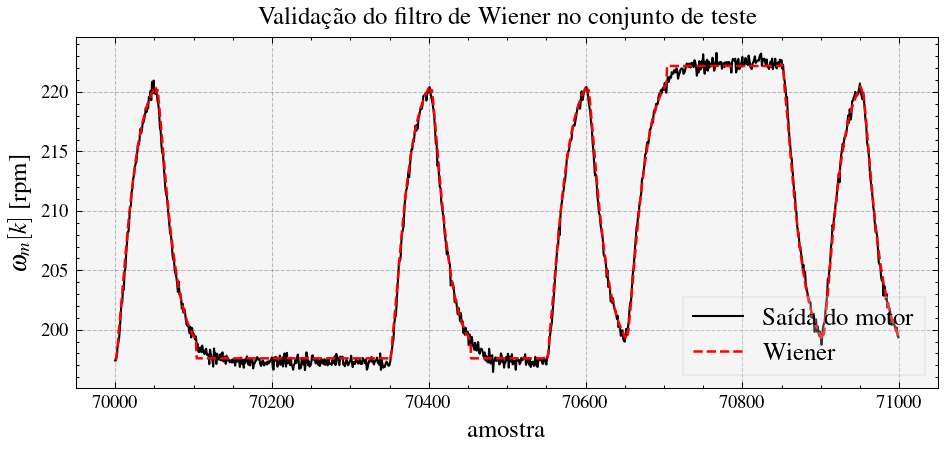

Time averaged MSE:


<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [50]:
# Calculate estimated system output
y_hat = signal.lfilter(h_opt, [1.0], x)
y_hat_rpm = y_hat + y0

mse_wiener_train = np.mean((d_train[Ntaps:] - y_hat[:n_train][Ntaps:])**2)
mse_wiener_test = np.mean((d_test[Ntaps:] - y_hat[n_train:][Ntaps:])**2)

idx0 = n_train
idx1 = n_train + 1000

samples = np.arange(idx0, idx1)

plt.figure(figsize=(6.5, 3.2))
plt.plot(samples, y[idx0:idx1], '-k', label='Saída do motor', linewidth=1)
plt.plot(samples, y_hat_rpm[idx0:idx1], '--r', label='Wiener', linewidth=1.2)

plt.xlabel('amostra')
plt.ylabel('$\\omega_m[k]$ [rpm]')
plt.title('Validação do filtro de Wiener no conjunto de teste')
plt.grid(True)
plt.legend(loc='lower right', frameon=True)

plt.tight_layout()
plt.savefig('wiener_saida_teste.png', dpi=300, bbox_inches='tight')
plt.show()

print('Time averaged MSE:')
symdisp('\\mathrm{MSE}_{train} =', sp.Matrix([mse_wiener_train])[0], numDig=4)
symdisp('\\mathrm{MSE}_{test} =', sp.Matrix([mse_wiener_test])[0], numDig=4)

## Least-Mean-Square (LMS) algorithm

O LMS é executado sobre os mesmos sinais usados para o filtro de Wiener. O objetivo é comparar a solução adaptativa com a referência ótima em lote.

No contexto do artigo, o LMS é relevante por sua simplicidade e baixo custo computacional. A cada iteração, os coeficientes FIR são corrigidos na direção do erro instantâneo entre a saída medida do motor e a saída estimada pelo filtro.

In [16]:
try:
    from numba import njit
except Exception:
    def njit(func):
        return func

@njit
def lms(x, d, Ntaps, mu):
    """
    The Least Mean Squares (LMS) algorithm.

    Parameters:
        x (ndarray): The input signal.
        d (ndarray): The reference signal.
        Ntaps (int): The number of filter taps.
        mu (float): The LMS step size.

    Returns:
        tuple: A tuple containing:
            - ndarray: The output signal.
            - ndarray: The final filter coefficients.
            - ndarray: The squared error at each iteration.

    """
    # Initialize the equalizer filter coefficients
    h = np.zeros(Ntaps)
    H = np.zeros((len(x)-Ntaps, Ntaps))
    ind = np.arange(0,Ntaps)

    # Apply the LMS algorithm
    squaredError = np.zeros(x.shape)
    out  = np.zeros(x.shape)

    # Iterate through each sample of the signal
    for i in range(Ntaps, len(x)):
        x_vec = x[i-ind]

        # Generate the estimated signal using the equalizer filter
        y = np.sum(x_vec * h)

        # Compute the error between the estimated signal and the reference signal
        error = d[i] - y

        # Update the filter coefficients using the LMS update rule
        h += 2 * mu * error * x_vec

        squaredError[i] = error**2
        out[i] = y
        H[i-Ntaps,:] = h

    return out, h, squaredError, H

### Example: DC motor system identification

Nesta etapa, o LMS identifica um filtro FIR com `Ntaps = Ncoefs`. A saída do filtro adaptativo é posteriormente comparada com a saída simulada do motor e com a saída do filtro de Wiener.

MSE LMS train = 0.2680
MSE LMS test = 0.2683
RMSE LMS test = 0.5180 rpm


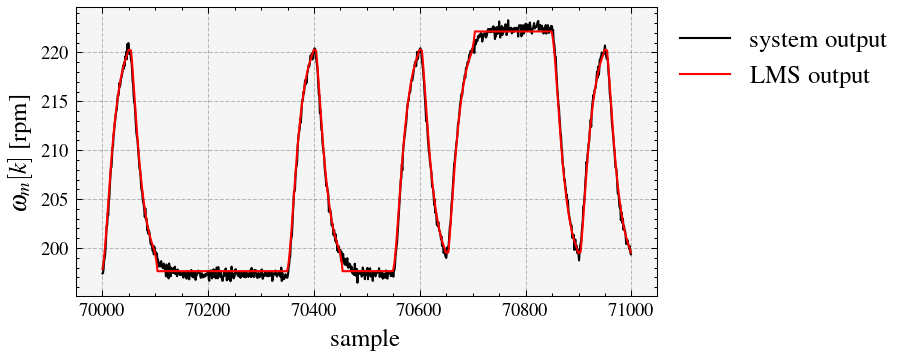

In [48]:
mu = 1e-4
Ntaps = Ncoefs
out, h, squaredError, H = lms(x_train, d_train, Ntaps, mu)

out_full = signal.lfilter(h, [1.0], x)
out_lms_rpm = out_full + y0

start = n_train
ind = np.arange(start,start+1000)

plt.plot(ind,y[ind],'-k',linewidth=1, label='system output')
plt.plot(ind,out_lms_rpm[ind],'-r',linewidth=1, label='LMS output')
plt.legend(bbox_to_anchor=(1, 1));
plt.xlabel('sample')
plt.ylabel('$\\omega_m[k]$ [rpm]')
plt.grid()

mse_lms_train = np.mean((d_train[Ntaps:] - out_full[:n_train][Ntaps:])**2)
mse_lms_test = np.mean((d_test[Ntaps:] - out_full[n_train:][Ntaps:])**2)

print(f'MSE LMS train = {mse_lms_train:.4f}')
print(f'MSE LMS test = {mse_lms_test:.4f}')
print(f'RMSE LMS test = {np.sqrt(mse_lms_test):.4f} rpm')

NameError: name 'mse_final' is not defined

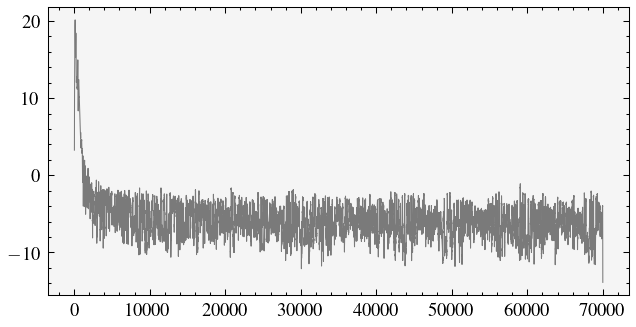

In [27]:
average_window_len = 50
error_dB_trial = power_to_db(np.convolve(squaredError,np.ones(average_window_len)/average_window_len, 'same'))
error_dB = power_to_db(np.convolve(squaredError,np.ones(average_window_len)/average_window_len, 'same'))
#emse = mmse_sys_id*np.sum(mu*eigenvalues_id/(1 - mu*eigenvalues_id)) # Calcula o EMSE para o valor atual de μ
#mse_final = 10*np.log10(mmse_sys_id + emse)  # Calcula o MSE final (MMSE + EMSE) para o valor atual de μ

plt.plot(error_dB_trial, label='LMS squared error', alpha=0.5)
#plt.plot(error_dB, label=f'LMS mean convergence curve ({1000} trials)')
plt.plot(mse_final*np.ones(len(error_dB)),'--', linewidth=1.25, label=f'MSE$_\\infty$ = {mse_final:.2f} dB')
plt.plot(10*np.log10(mmse_sys_id)*np.ones(len(error_dB)), linewidth=1, label='MMSE (Wiener filter) = ' + f'{10*np.log10(mmse_sys_id):.2f} dB')
plt.xlim(0,len(error_dB))
#plt.ylim(-21, -19)
plt.xlabel('iteration')
plt.ylabel('$e^2[k]$ [dB]')
plt.legend(bbox_to_anchor=(1, 1));
plt.grid();

MSE Wiener treino = 0.2502
MSE Wiener teste  = 0.2494
MSE LMS treino    = 0.2680
MSE LMS teste     = 0.2683


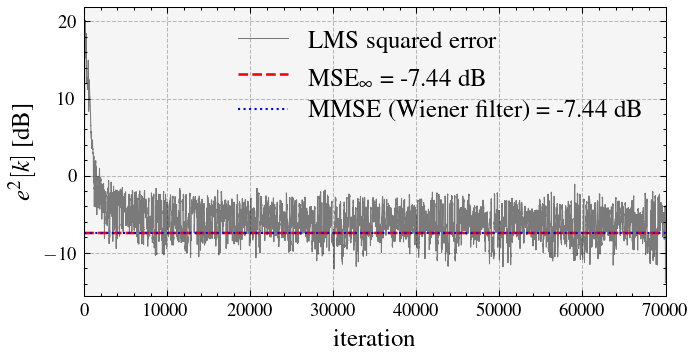

In [31]:
average_window_len = 50

# Smooth LMS squared error using a moving average
mse_curve = np.convolve(
    squaredError,
    np.ones(average_window_len)/average_window_len,
    mode='same'
)

error_dB = power_to_db(mse_curve)

# Eigenvalues of the input correlation matrix
eigenvalues = np.linalg.eigvalsh(R)

# Theoretical steady-state excess MSE for LMS
emse = mmse_sys_id * np.sum(mu*eigenvalues/(1 - mu*eigenvalues))
mse_inf = mmse_sys_id + emse

plt.plot(error_dB, label='LMS squared error', alpha=0.5)
plt.plot(
    10*np.log10(mse_inf)*np.ones(len(error_dB)),
    '--',
    linewidth=1.25,
    label=f'MSE$_\\infty$ = {10*np.log10(mse_inf):.2f} dB'
)
plt.plot(
    10*np.log10(mmse_sys_id)*np.ones(len(error_dB)),
    linewidth=1,
    label=f'MMSE (Wiener filter) = {10*np.log10(mmse_sys_id):.2f} dB'
)

plt.xlim(0, len(error_dB))
plt.xlabel('iteration')
plt.ylabel('$e^2[k]$ [dB]')
plt.legend(bbox_to_anchor=(1, 1))
plt.grid()

print(f'MSE Wiener treino = {mse_wiener_train:.4f}')
print(f'MSE Wiener teste  = {mse_wiener_test:.4f}')
print(f'MSE LMS treino    = {mse_lms_train:.4f}')
print(f'MSE LMS teste     = {mse_lms_test:.4f}')

MSE Wiener treino = 0.2502
MSE Wiener teste  = 0.2494
MSE LMS treino    = 0.2680
MSE LMS teste     = 0.2683
Erro relativo entre h_LMS e h_opt = 0.3452


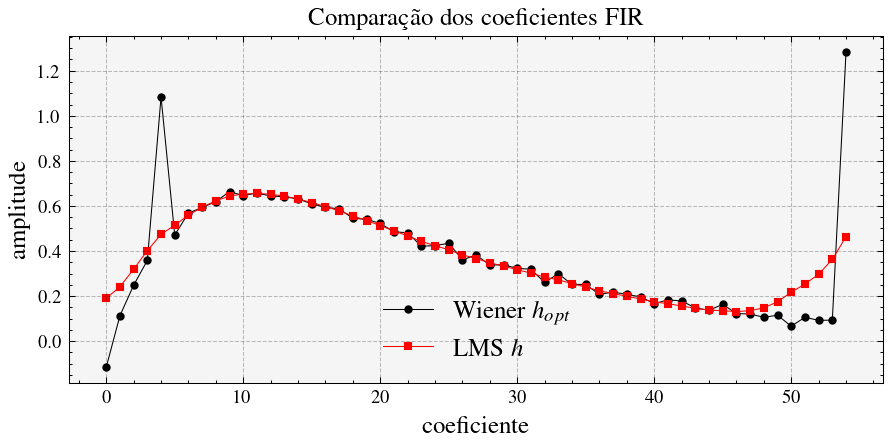

In [32]:
mse_lms_train = np.mean((d_train[Ntaps:] - out_full[:n_train][Ntaps:])**2)
mse_lms_test = np.mean((d_test[Ntaps:] - out_full[n_train:][Ntaps:])**2)

print(f'MSE Wiener treino = {mse_wiener_train:.4f}')
print(f'MSE Wiener teste  = {mse_wiener_test:.4f}')
print(f'MSE LMS treino    = {mse_lms_train:.4f}')
print(f'MSE LMS teste     = {mse_lms_test:.4f}')

coef_error = np.linalg.norm(h - h_opt) / np.linalg.norm(h_opt)
print(f'Erro relativo entre h_LMS e h_opt = {coef_error:.4f}')

plt.figure(figsize=(7,3))
plt.plot(h_opt, '-ok', label='Wiener $h_{opt}$', markersize=3)
plt.plot(h, '-sr', label='LMS $h$', markersize=3)
plt.xlabel('coeficiente')
plt.ylabel('amplitude')
plt.title('Comparação dos coeficientes FIR')
plt.grid()
plt.legend();

In [ ]:
symdisp('\\boldsymbol{h}_{\\mathrm{LMS}} = ', sp.Matrix(h), numDig=3)
symdisp('\\boldsymbol{h}_{opt} = ', sp.Matrix(h_opt), numDig=3)

## The normalized LMS algorithm (NLMS)

O NLMS normaliza o passo de adaptação pela energia do vetor de entrada. Assim, a atualização dos coeficientes é dada por

$$
\boldsymbol{h}[k+1] =
\boldsymbol{h}[k] +
\frac{\mu e[k]\boldsymbol{x}[k]}
{\gamma + \boldsymbol{x}^T[k]\boldsymbol{x}[k]},
$$

em que $\gamma$ evita valores elevados do passo efetivo quando a energia da entrada é pequena. A implementação e as comparações abaixo seguem o padrão usado no notebook **Variants of LMS algorithm**.

No artigo, o NLMS é avaliado como uma alternativa ao LMS para lidar com variações de amplitude da entrada. Nesta replicação, ele é comparado ao LMS usando os mesmos dados, o mesmo comprimento FIR e a mesma métrica de erro.

In [33]:
@njit
def nlms(x, d, Ntaps, mu, gamma=1e-6):
    """
    The Normalized Least Mean Squares (NLMS) algorithm.

    Parameters:
        x (ndarray): The input signal.
        d (ndarray): The reference signal.
        Ntaps (int): The number of filter taps.
        mu (float): The NLMS step size.
        gamma (float): Parameter to avoid large step sizes when the norm of the input vector is small.

    Returns:
        tuple: A tuple containing:
            - ndarray: The output signal.
            - ndarray: The final filter coefficients.
            - ndarray: The squared error at each iteration.

    """
    # Initialize the equalizer filter coefficients
    h = np.zeros((Ntaps,1), dtype=np.float64)
    H = np.zeros((len(x)-Ntaps, Ntaps), dtype=np.float64)
    ind = np.arange(0,Ntaps)

    # Apply the NLMS algorithm
    squaredError = np.zeros(x.shape, dtype=np.float64)
    out = np.zeros(x.shape, dtype=np.float64)
    x = x.reshape(-1,1).astype(np.float64)

    # Iterate through each sample of the signal
    for i in range(Ntaps, x.shape[0]):
        x_vec = x[i-ind,:]

        # Generate the estimated signal using the adaptive filter
        y_nlms = np.sum(x_vec * h)

        # Compute the error between the estimated signal and the reference signal
        error = d[i] - y_nlms

        # Update the filter coefficients using the NLMS update rule
        h += mu * error * x_vec/(gamma + x_vec.T@x_vec)

        squaredError[i] = error**2
        out[i] = y_nlms
        H[i-Ntaps,:] = h.T

    return out, h, squaredError, H

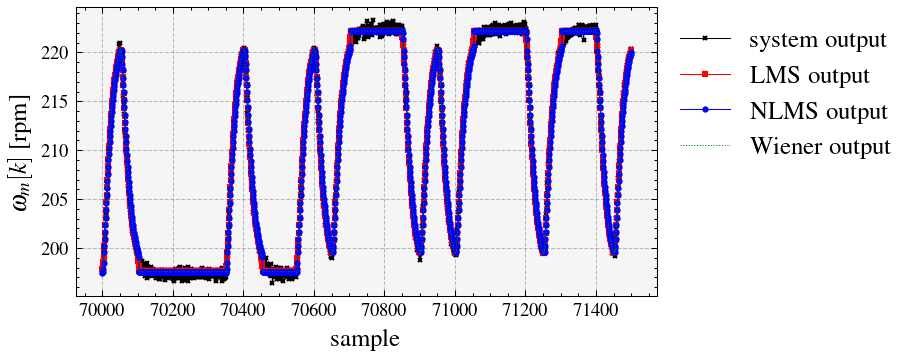

In [34]:
mu_lms = 1e-4
mu_nlms = 0.1
gamma = 1e-6
Ntaps = Ncoefs

# Run LMS and NLMS using the same motor identification data
out_lms, h_lms, squaredError_lms, H_lms = lms(x_train, d_train, Ntaps, mu_lms)
out_nlms, h_nlms, squaredError_nlms, H_nlms = nlms(x_train, d_train, Ntaps, mu_nlms, gamma)

# Apply the final adaptive filters to the complete input signal
out_lms_full = signal.lfilter(h_lms, [1.0], x)
out_nlms_full = signal.lfilter(np.squeeze(h_nlms), [1.0], x)

out_lms_rpm = out_lms_full + y0
out_nlms_rpm = out_nlms_full + y0

start = n_train
ind = np.arange(start,start+1500)

# Compare results:
plt.figure()
plt.plot(ind, y[ind],'-xk', label='system output')
plt.plot(ind,out_lms_rpm[ind],'-sr', label='LMS output')
plt.plot(ind,out_nlms_rpm[ind],'-ob', label='NLMS output')
plt.plot(ind,y_hat_rpm[ind],':g', label='Wiener output')
plt.xlabel('sample')
plt.ylabel('$\\omega_m[k]$ [rpm]')
plt.legend(bbox_to_anchor=(1, 1));
plt.grid()

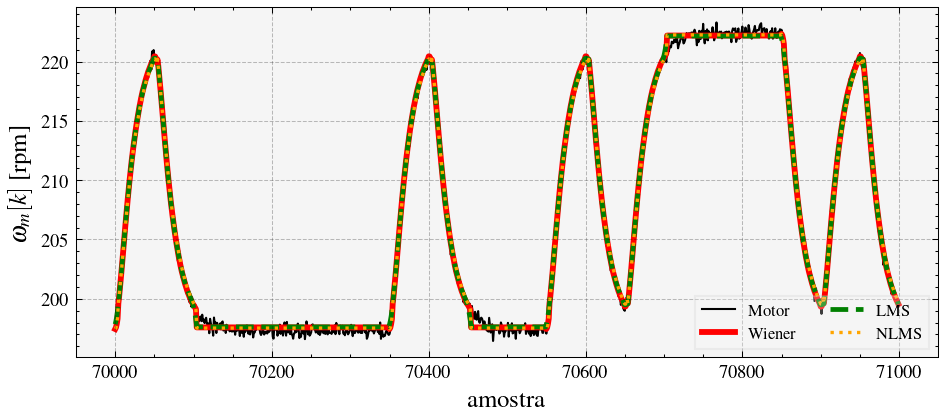

In [76]:
idx0 = n_train
idx1 = n_train + 1000
samples = np.arange(idx0, idx1)

plt.figure(figsize=(6.5, 3.0))

plt.plot(samples, y[idx0:idx1],
         color='k', linewidth=1, label='Motor')

plt.plot(samples, y_hat_rpm[idx0:idx1],
         color='r', linestyle='-', linewidth=2.8, label='Wiener')

plt.plot(samples, out_lms_rpm[idx0:idx1],
         color='g', linestyle='--', linewidth=2.3, label='LMS')

plt.plot(samples, out_nlms_rpm[idx0:idx1],
         color='orange', linestyle=':', linewidth=1.6, label='NLMS')

plt.xlabel('amostra')
plt.ylabel('$\\omega_m[k]$ [rpm]')
plt.grid(True)

plt.legend(
    loc='lower right',
    fontsize=8,
    frameon=True,
    ncol=2
)

plt.tight_layout()
plt.savefig('comparacao_saida_wiener_lms_nlms.png', dpi=300, bbox_inches='tight')
plt.show()

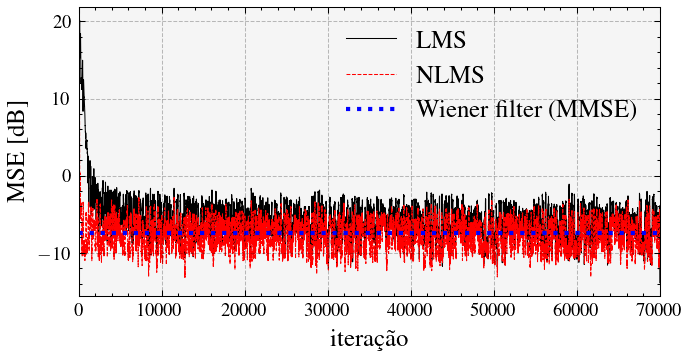

In [52]:
average_window_len = 50
mse_lms_dB = power_to_db(np.convolve(squaredError_lms,np.ones(average_window_len)/average_window_len, 'same'))
mse_nlms_dB = power_to_db(np.convolve(squaredError_nlms,np.ones(average_window_len)/average_window_len, 'same'))

plt.figure()
plt.plot(mse_lms_dB, label='LMS')
plt.plot(mse_nlms_dB, label='NLMS')
plt.plot(10*np.log10(mmse_sys_id)*np.ones(len(mse_lms_dB)), linewidth=2, label='Wiener filter (MMSE)')
plt.xlim(0,len(mse_lms_dB))
plt.xlabel('iteração')
plt.ylabel('$\\mathrm{MSE}$ [dB]')
plt.legend(bbox_to_anchor=(1, 1));
plt.grid();

In [53]:
# Calculate train and test MSE for the three identification methods
mse_lms_train = np.mean(squaredError_lms[Ntaps:])
mse_nlms_train = np.mean(squaredError_nlms[Ntaps:])

mse_lms_test = np.mean((d_test[Ntaps:] - out_lms_full[n_train:][Ntaps:])**2)
mse_nlms_test = np.mean((d_test[Ntaps:] - out_nlms_full[n_train:][Ntaps:])**2)

print(f'MSE Wiener treino = {mse_wiener_train:.4f}')
print(f'MSE Wiener teste  = {mse_wiener_test:.4f}')
print(f'MSE LMS treino    = {mse_lms_train:.4f}')
print(f'MSE LMS teste     = {mse_lms_test:.4f}')
print(f'MSE NLMS treino   = {mse_nlms_train:.4f}')
print(f'MSE NLMS teste    = {mse_nlms_test:.4f}')

MSE Wiener treino = 0.2502
MSE Wiener teste  = 0.2494
MSE LMS treino    = 0.5931
MSE LMS teste     = 0.2683
MSE NLMS treino   = 0.2029
MSE NLMS teste    = 0.2717


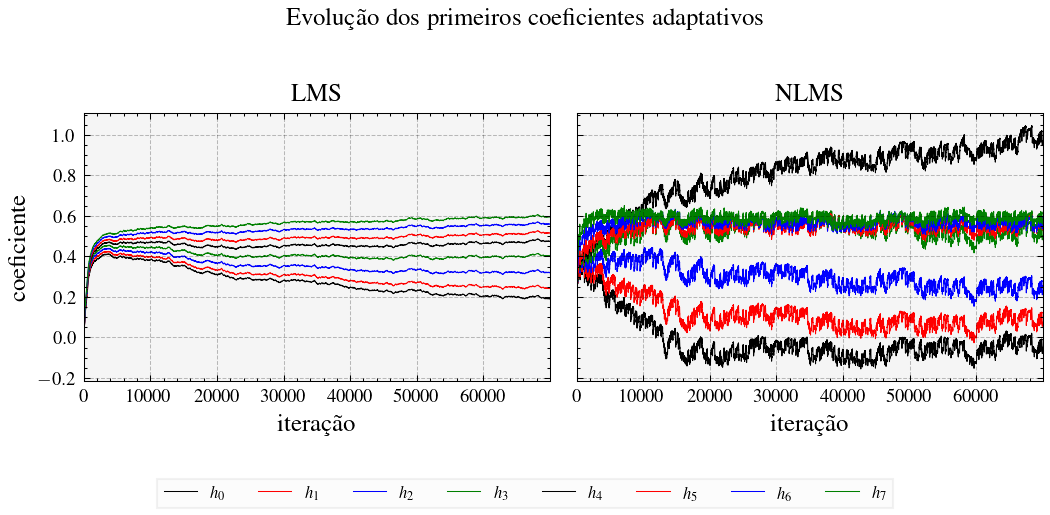

In [65]:
fig, ax = plt.subplots(1, 2, figsize=(7.2, 3.2), sharey=True)

n_coefs_plot = min(Ntaps, 8)

# LMS coefficient evolution
for k in range(n_coefs_plot):
    ax[0].plot(H_lms[:, k], '-', linewidth=0.5, label=f'$h_{k}$')

ax[0].set_xlabel('iteração')
ax[0].set_ylabel('coeficiente')
ax[0].set_title('LMS')
ax[0].grid(True)
ax[0].set_xlim(0, H_lms.shape[0])

# NLMS coefficient evolution
for k in range(n_coefs_plot):
    ax[1].plot(H_nlms[:, k], '-', linewidth=0.5, label=f'$h_{k}$')

ax[1].set_xlabel('iteração')
ax[1].set_title('NLMS')
ax[1].grid(True)
ax[1].set_xlim(0, H_nlms.shape[0])

# Shared legend below both plots
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc='lower center',
    ncol=8,
    frameon=True,
    fontsize=8,
    bbox_to_anchor=(0.5, -0.04)
)

fig.suptitle('Evolução dos primeiros coeficientes adaptativos', y=1.02)

fig.tight_layout(rect=[0, 0.08, 1, 1])
plt.savefig('coeficientes_lms_nlms.png', dpi=300, bbox_inches='tight')
plt.show()

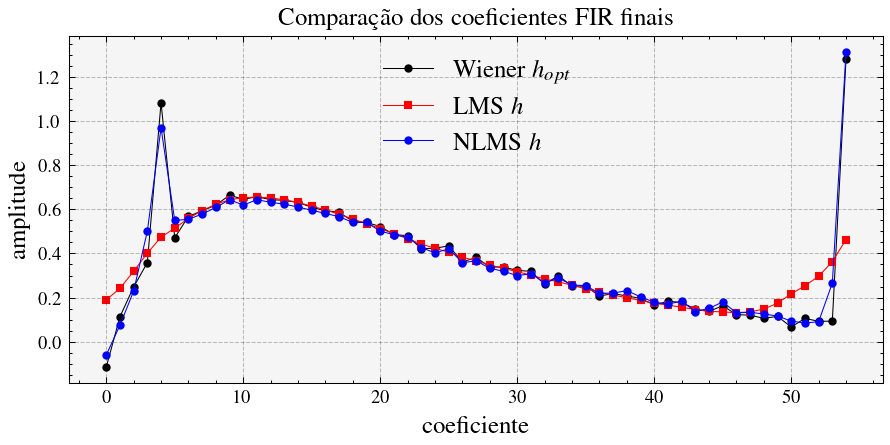

In [55]:
plt.figure(figsize=(7,3))
plt.plot(h_opt, '-ok', label='Wiener $h_{opt}$', markersize=3)
plt.plot(h_lms, '-sr', label='LMS $h$', markersize=3)
plt.plot(np.squeeze(h_nlms), '-ob', label='NLMS $h$', markersize=3)
plt.xlabel('coeficiente')
plt.ylabel('amplitude')
plt.title('Comparação dos coeficientes FIR finais')
plt.grid()
plt.legend()

In [56]:
symdisp('\\boldsymbol{h}_{\\mathrm{LMS}} = ', sp.Matrix(h_lms), numDig=3)
symdisp('\\boldsymbol{h}_{\\mathrm{NLMS}} = ', sp.Matrix(np.squeeze(h_nlms)), numDig=3)
symdisp('\\boldsymbol{h}_{opt} = ', sp.Matrix(h_opt), numDig=3)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

### Average Squared Error (ASE)

O ASE é calculado conforme a definição apresentada no artigo:

$$
\mathrm{ASE} =
\frac{1}{L}
\sum_{k=0}^{L-1}
\left(d(k)-y(k)\right)^2,
$$

em que $L$ é o número de amostras avaliadas, $d(k)$ é a saída desejada e $y(k)$ é a saída estimada pelo filtro. Neste notebook, o ASE é calculado sobre o conjunto de teste, após descartar as primeiras `Ntaps` amostras necessárias para formar o vetor de entrada do filtro FIR.

Essa definição produz um único valor por algoritmo, o que permite comparar diretamente a qualidade final da identificação.

In [57]:
def calculate_ase(d, y):
    '''Calculate ASE according to Equation (14) of the article.'''
    return np.sum((d-y)**2)/len(d)


# Calculate ASE over the test interval for Wiener, LMS and NLMS
ase_wiener = calculate_ase(
    d_test[Ntaps:],
    y_hat[n_train:][Ntaps:],
)
ase_lms = calculate_ase(
    d_test[Ntaps:],
    out_lms_full[n_train:][Ntaps:],
)
ase_nlms = calculate_ase(
    d_test[Ntaps:],
    out_nlms_full[n_train:][Ntaps:],
)

print(f'ASE Wiener = {ase_wiener:.5f}')
print(f'ASE LMS    = {ase_lms:.5f}')
print(f'ASE NLMS   = {ase_nlms:.5f}')

ASE Wiener = 0.24941
ASE LMS    = 0.26831
ASE NLMS   = 0.27167


### Algorithm comparisons

A tabela final segue o formato de comparação usado no artigo, apresentando o ASE e os tempos de processamento com e sem downsampling.

O fator de downsampling usado nesta análise é definido abaixo. O custo do pré-processamento de decimação não é incluído: são medidos apenas os tempos de identificação dos algoritmos. O mesmo número de coeficientes, `Ntaps`, é mantido nos dois casos.

Como AP e RLS ainda não foram implementados neste notebook, a tabela apresenta apenas Wiener, LMS e NLMS. O ASE de todos os métodos é calculado no mesmo conjunto de teste segundo a Equação (14) do artigo.

A comparação deve ser interpretada como uma versão computacional do estudo de caso: os valores absolutos não precisam coincidir com os do artigo, pois a planta e os dados são simulados, mas a organização da avaliação segue a mesma lógica.

In [58]:
def wiener_identification(x, d, Ntaps):
    '''Run the complete batch Wiener identification procedure.'''
    R_wiener = estimate_correlation_matrix(x, Ntaps)
    p_wiener = estimate_cross_correlation(x, d, Ntaps)
    h_wiener = np.linalg.pinv(R_wiener)@p_wiener
    return h_wiener


def average_processing_time(function, args, repeats=5):
    '''Measure the average processing time of a function.'''
    processing_times = np.zeros(repeats)

    for repetition in range(repeats):
        start_time = time.perf_counter()
        function(*args)
        processing_times[repetition] = time.perf_counter() - start_time

    return np.mean(processing_times)


n_benchmark = 3
downsampling_factor = 10

# Downsample the identification data before measuring the algorithm time.
# The preprocessing time is intentionally excluded from the benchmark.
x_train_downsampled = np.ascontiguousarray(signal.decimate(
    x_train, downsampling_factor, zero_phase=True
))
d_train_downsampled = np.ascontiguousarray(signal.decimate(
    d_train, downsampling_factor, zero_phase=True
))

# Measure processing time without downsampling
time_wiener_without_downsampling = average_processing_time(
    wiener_identification, (x_train, d_train, Ntaps), n_benchmark
)
time_lms_without_downsampling = average_processing_time(
    lms, (x_train, d_train, Ntaps, mu_lms), n_benchmark
)
time_nlms_without_downsampling = average_processing_time(
    nlms, (x_train, d_train, Ntaps, mu_nlms, gamma), n_benchmark
)

# Measure processing time with downsampling
time_wiener_with_downsampling = average_processing_time(
    wiener_identification,
    (x_train_downsampled, d_train_downsampled, Ntaps),
    n_benchmark,
)
time_lms_with_downsampling = average_processing_time(
    lms,
    (x_train_downsampled, d_train_downsampled, Ntaps, mu_lms),
    n_benchmark,
)
time_nlms_with_downsampling = average_processing_time(
    nlms,
    (x_train_downsampled, d_train_downsampled, Ntaps, mu_nlms, gamma),
    n_benchmark,
)

print(f'Downsampling factor = {downsampling_factor}')
print(f'Samples without downsampling = {len(x_train)}')
print(f'Samples with downsampling    = {len(x_train_downsampled)}')

Downsampling factor = 10
Samples without downsampling = 70000
Samples with downsampling    = 7000


In [59]:
# ALGORITHM COMPARISONS
comparison_records = [
    {
        'Algorithm': 'Wiener',
        'ASE': ase_wiener,
        'Time with downsampling': time_wiener_with_downsampling,
        'Time without downsampling': time_wiener_without_downsampling,
    },
    {
        'Algorithm': 'LMS',
        'ASE': ase_lms,
        'Time with downsampling': time_lms_with_downsampling,
        'Time without downsampling': time_lms_without_downsampling,
    },
    {
        'Algorithm': 'NLMS',
        'ASE': ase_nlms,
        'Time with downsampling': time_nlms_with_downsampling,
        'Time without downsampling': time_nlms_without_downsampling,
    },
]

try:
    import pandas as pd

    comparison_table = pd.DataFrame(comparison_records)
    comparison_table['ASE'] = comparison_table['ASE'].map(
        lambda value: f'{value:.5f}'
    )
    comparison_table['Time with downsampling'] = comparison_table[
        'Time with downsampling'
    ].map(lambda value: f'{value:.5f} sec')
    comparison_table['Time without downsampling'] = comparison_table[
        'Time without downsampling'
    ].map(lambda value: f'{value:.5f} sec')

    display(comparison_table)
except Exception:
    comparison_table = comparison_records
    comparison_table

,Algorithm,ASE,Time with downsampling,Time without downsampling
0,Wiener,0.24941,0.04299 sec,0.49130 sec
1,LMS,0.26831,0.00499 sec,0.03542 sec
2,NLMS,0.27167,0.00800 sec,0.05215 sec


### Convergence behavior for different values of step-size

O passo de adaptação controla o compromisso entre velocidade de convergência e erro em regime. Valores elevados tendem a acelerar a adaptação, mas podem aumentar oscilações ou degradar a estimação final. Valores menores geralmente produzem adaptação mais lenta, porém mais estável.

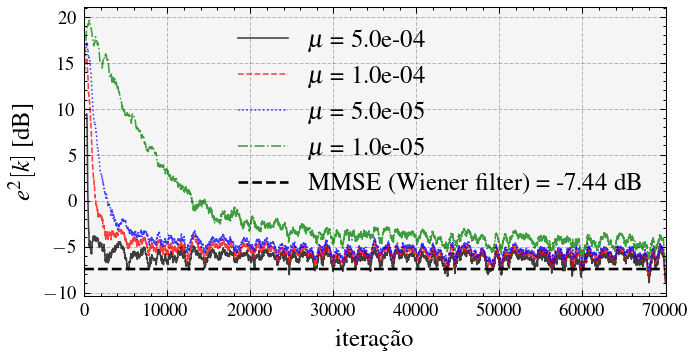

In [61]:
Ntaps = Ncoefs
average_window_len = 500

muValues = [5e-4, 1e-4, 5e-5, 1e-5]
for mu in muValues:
    out_mu, h_mu, squaredError_mu, H_mu = lms(x_train, d_train, Ntaps, mu)
    error_dB = power_to_db(np.convolve(squaredError_mu,np.ones(average_window_len)/average_window_len, 'same'))
    plt.plot(error_dB, label= f'$\\mu$ = {mu:.1e}', alpha=0.75, linewidth=0.75)

plt.plot(10*np.log10(mmse_sys_id)*np.ones(len(error_dB)),'--', linewidth=1.25, label=f'MMSE (Wiener filter) = {10*np.log10(mmse_sys_id):.2f} dB', color='k')
plt.xlim(0,len(error_dB))
plt.xlabel('iteração')
plt.ylabel('$e^2[k]$ [dB]')
plt.legend(bbox_to_anchor=(1, 1))
plt.grid();

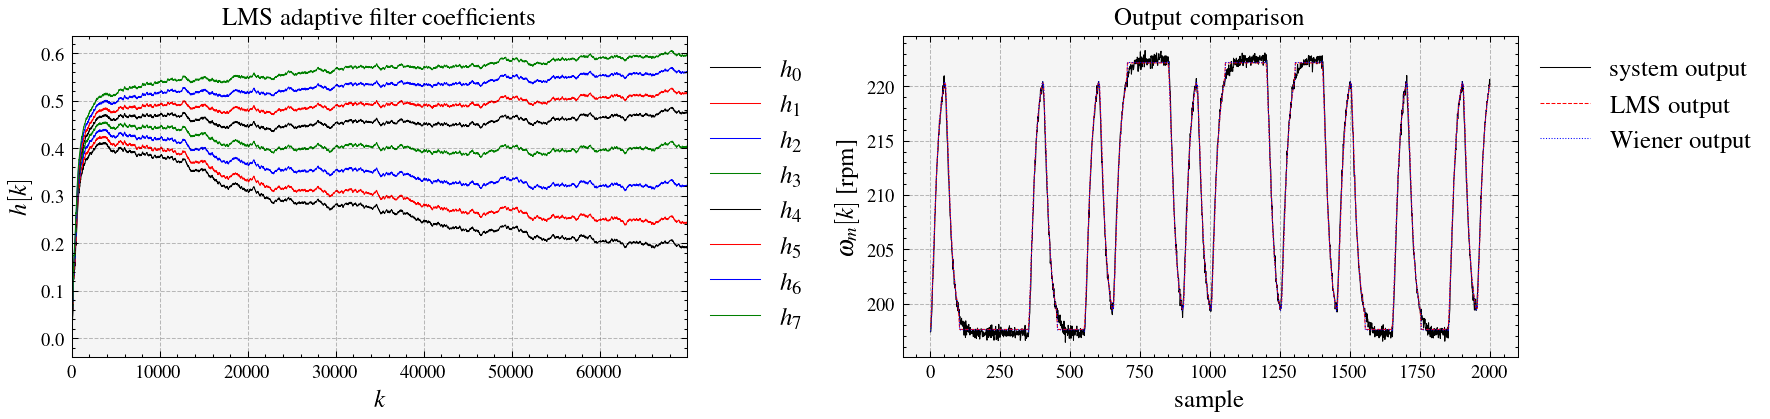

In [28]:
fig, ax = plt.subplots(1,2,figsize=(12,3))

for k in range(min(Ntaps, 8)):
    ax[0].plot(H[:,k],'-',label = f'$h_{k}$')

ax[0].set_xlabel('$k$')
ax[0].set_ylabel('$\\boldsymbol{h}[k]$')
ax[0].legend(bbox_to_anchor=(1, 1))
ax[0].grid();
ax[0].set_xlim(0, H.shape[0])
ax[0].set_title('LMS adaptive filter coefficients')

ax[1].plot(y[n_train:n_train+2000],'-k', label='system output')
ax[1].plot(out_lms_rpm[n_train:n_train+2000],'--r', label='LMS output')
ax[1].plot(y_hat_rpm[n_train:n_train+2000],':b', label='Wiener output')
ax[1].set_xlabel('sample')
ax[1].set_ylabel('$\\omega_m[k]$ [rpm]')
ax[1].legend(bbox_to_anchor=(1, 1))
ax[1].grid();
ax[1].set_title('Output comparison')

plt.tight_layout()

## Observações finais

Este notebook mantém o pipeline do notebook de referência: estimação estatística, filtro de Wiener, LMS, NLMS e comparação por ASE/tempo de processamento. As próximas adaptações devem concentrar-se em calibrar os parâmetros físicos do motor, a amplitude/período do PRBS e o valor de $\mu$ com base no artigo.

Em relação ao artigo, esta versão já reproduz os elementos centrais da análise: identificação FIR do motor, uso de $M=55$ coeficientes, avaliação por ASE e comparação de tempo com e sem downsampling. As extensões naturais são implementar AP e RLS, ajustar os hiperparâmetros por algoritmo e aproximar a geração dos dados do experimento original.